In [2]:
import xarray as xr
#from datetime import datetime
#import math
#import numpy as np
#import geopandas as gpd
#import rioxarray as rio
#import matplotlib.pyplot as plt

In [ ]:
'''
take hourly data and make daily in appropriate way
    - daily max temp (tasmax): daily max from hourly maximum t2m (mx2t)
    - daily u/v wind component: daily mean from hourly u/v
    - daily min dew point temp (min_dt): daily min from hourly d2m
    - daily precip (tp): daily sum from hourly tp
'''

def process_variables(date):
    ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/hourly/post_1951/ERA5-hourly-' + date + '.nc')

    da = ds['mx2t'].resample(time='D').max()
    da.to_netcdf('/nesi/project/niwa00015/queenle/data/ERA5/daily/max_t2m/max_t2m_'+date+'.nc')
    
    da = ds['u10'].resample(time='D').mean()
    da.to_netcdf('/nesi/project/niwa00015/queenle/data/ERA5/daily/uwind/uwind_'+date+'.nc')
    
    da = ds['v10'].resample(time='D').mean()
    da.to_netcdf('/nesi/project/niwa00015/queenle/data/ERA5/daily/vwind/vwind_'+date+'.nc')
    
    da = ds['d2m'].resample(time='D').min()
    da.to_netcdf('/nesi/project/niwa00015/queenle/data/ERA5/daily/min_d2m/min_d2m_'+date+'.nc')
    
    da = ds['tp'].resample(time='D').sum()
    da.to_netcdf('/nesi/project/niwa00015/queenle/data/ERA5/daily/tp/tp_'+date+'.nc')

for year in range(1951,2022):
    print(year)
    for month in range(1,13):
        date = str(year) + '-' + '0' + str(month) if month < 10 else str(year) + '-' + str(month)
        
        process_variables(date)
        
        break
    break

In [3]:
ds

<xarray.Dataset>
Dimensions:    (latitude: 205, longitude: 133, time: 744)
Coordinates:
  * longitude  (longitude) float32 -137.0 -136.8 -136.5 ... -104.5 -104.2 -104.0
  * latitude   (latitude) float32 71.0 70.75 70.5 70.25 ... 20.5 20.25 20.0
  * time       (time) datetime64[ns] 1951-01-01 ... 1951-01-31T23:00:00
Data variables:
    i10fg      (time, latitude, longitude) float32 ...
    tp         (time, latitude, longitude) float32 ...
    u10        (time, latitude, longitude) float32 ...
    v10        (time, latitude, longitude) float32 ...
    d2m        (time, latitude, longitude) float32 ...
    t2m        (time, latitude, longitude) float32 ...
    mx2t       (time, latitude, longitude) float32 ...
Attributes:
    Conventions:  CF-1.6
    history:      2023-05-10 04:12:52 GMT by grib_to_netcdf-2.25.1: /opt/ecmw...

In [2]:
'''
LOAD DATA
'''

# ERA5 land-sea mask
lsm = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/static/land_sea_mask.nc')
lsm = lsm.isel(time=0).drop('time')
lsm.rio.write_crs("epsg:4326", inplace=True)

# time zone shape file
tz_data = gpd.read_file("/nesi/project/niwa00015/queenle/data/time_zones/ne_10m_time_zones.shp")

# hourly ERA5 data
ERA5_hourly_ds = xr.open_dataset("/nesi/project/niwa00015/queenle/data/ERA5/hourly/post_79/ERA5-hourly-1979_2021.nc")


In [6]:
t2m_max_hourly = xr.open_dataset("/nesi/project/niwa00015/queenle/data/ERA5/hourly/post_1951/t2m_max/ERA5_hourly_1951_2022.nc")


In [7]:
t2m_max_hourly

<xarray.Dataset>
Dimensions:    (latitude: 89, longitude: 77, time: 631152)
Coordinates:
  * time       (time) datetime64[ns] 1951-01-01 ... 2022-12-31T23:00:00
  * longitude  (longitude) float32 -129.0 -128.8 -128.5 ... -110.5 -110.2 -110.0
  * latitude   (latitude) float32 52.0 51.75 51.5 51.25 ... 30.5 30.25 30.0
Data variables:
    mx2t       (time, latitude, longitude) float64 ...
Attributes:
    CDI:          Climate Data Interface version 2.0.5 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Wed May 10 14:10:34 2023: cdo -b F64 -mergetime ERA5-hourly...
    CDO:          Climate Data Operators version 2.0.5 (https://mpimet.mpg.de...

In [3]:
'''
CREATE LAND/TIME ZONE MASKS
'''

#zone=-8.0; tz_name1st = America/Los_Angeles
tz1 = tz_data.loc[tz_data.tz_name1st=='America/Los_Angeles'].geometry 
tz1_offset = tz_data.loc[tz_data.tz_name1st=='America/Los_Angeles'].zone.values[0]
tz1_noon_utc = 12 - tz1_offset # 12UTC - (-8) = 20UTC = local noon tz1 (PST)
tz1_mask = lsm.rio.clip(tz1, tz1.crs,drop=False).fillna(0)

#zone=-7.0; tz_name1st = America/Denver
tz2 = tz_data.loc[tz_data.tz_name1st=='America/Denver'].geometry 
tz2_offset = tz_data.loc[tz_data.tz_name1st=='America/Denver'].zone.values[0]
tz2_noon_utc = 12 - tz2_offset # 12UTC - (-7) = 19UTC = local noon tz2 (MST)
tz2_mask = lsm.rio.clip(tz2, tz2.crs,drop=False).fillna(0)

In [50]:
# 20 UTC
t2m = ERA5_hourly_ds.t2m
t2m_20 = t2m.resample(time="24H", base = tz1_noon_utc, closed="right",label="right").last()

t2m_20 = t2m_20.where((tz1_mask + tz2_mask).lsm > 0)
t2m_20 = t2m_20 - 273.15
t2m_20 = t2m_20.sel(time=slice('1979','2011'))

# 19 UTC
t2m_19 = t2m.resample(time="24H", base = tz2_noon_utc, closed="right",label="right").last()

t2m_19 = t2m_19.where((tz1_mask + tz2_mask).lsm > 0)
t2m_19 = t2m_19 - 273.15
t2m_19 = t2m_19.sel(time=slice('1979','2011'))

PST = t2m_20.where(tz1_mask.lsm > 0, other=0)
MST = t2m_19.where(tz2_mask.lsm > 0, other=0)

PST['time'] = PST.indexes['time'].normalize()
MST['time'] = MST.indexes['time'].normalize()

mixed = PST + MST

In [29]:
'''
calculate tasmax
'''

tasmax = t2m_max_hourly.mx2t.resample(time="D").max()
tasmax = tasmax.where((tz1_mask + tz2_mask).lsm > 0)
tasmax = tasmax - 273.15


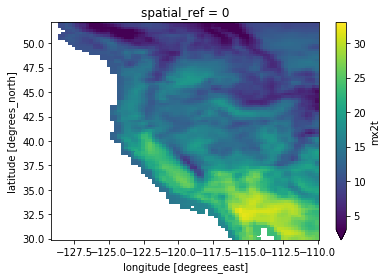

In [35]:
tasmax.sel(time=slice('1951','2011')).mean('time').plot(vmin=3,vmax=33)

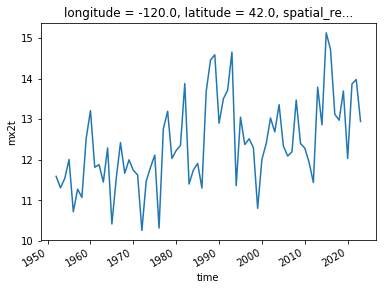

In [30]:
cell = tasmax.sel(latitude=42,longitude=-120)
cell.resample(time='A').mean().plot()

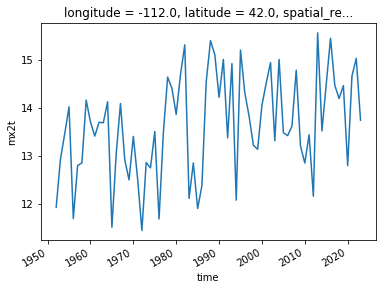

In [32]:
cell = tasmax.sel(latitude=42,longitude=-112)
cell.resample(time='A').mean().plot()

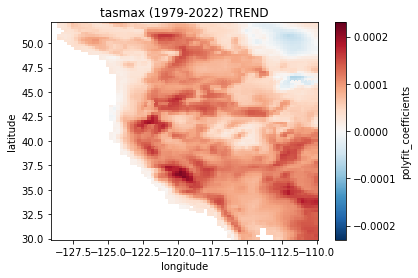

In [24]:
#tasmax.mean('time').plot(vmin=3,vmax=33)

poly_fit = tasmax.sel(time=slice('1979','2022')).polyfit(dim='time',deg=1,skipna=True)
(poly_fit.polyfit_coefficients.sel(degree=1)* 1e9 * 60 * 60 * 24).plot(vmin=-0.00023,vmax=0.00023,cmap='RdBu_r')
plt.title('tasmax (1979-2022) TREND')
plt.savefig('/nesi/project/niwa00015/queenle/plots/fire/ERA5_tasmax_trend_1979_2022.png')

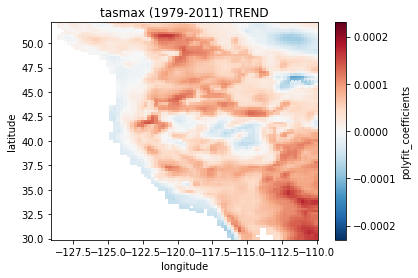

In [25]:
#tasmax_subset.mean('time').plot(vmin=3,vmax=33)

poly_fit = tasmax.sel(time=slice('1979','2011')).polyfit(dim='time',deg=1,skipna=True)
(poly_fit.polyfit_coefficients.sel(degree=1)* 1e9 * 60 * 60 * 24).plot(vmin=-0.00023,vmax=0.00023,cmap='RdBu_r')
plt.title('tasmax (1979-2011) TREND')
plt.savefig('/nesi/project/niwa00015/queenle/plots/fire/ERA5_tasmax_trend_1979_2011.png')

Text(0.5, 1.0, 'tasmax (1951-2011) TREND')

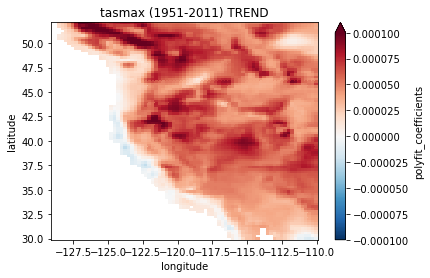

In [36]:
#tasmax_subset.mean('time').plot(vmin=3,vmax=33)

poly_fit = tasmax.sel(time=slice('1951','2011')).polyfit(dim='time',deg=1,skipna=True)
(poly_fit.polyfit_coefficients.sel(degree=1)* 1e9 * 60 * 60 * 24).plot(vmin=-0.0001,vmax=0.0001,cmap='RdBu_r')
plt.title('tasmax (1951-2011) TREND')
#plt.savefig('/nesi/project/niwa00015/queenle/plots/fire/ERA5_tasmax_trend_1951_2011.png')

In [13]:
mixed = mixed.where((tz1_mask+tz2_mask).lsm > 0)

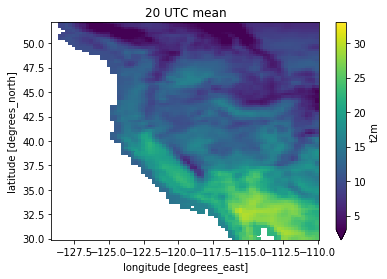

In [15]:
t2m_20.mean('time').plot(vmin=3,vmax=33)
plt.title('20 UTC mean')
plt.savefig('/nesi/project/niwa00015/queenle/plots/fire/20UTCmean.png')

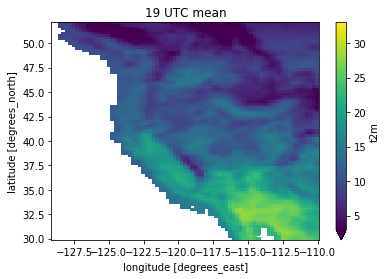

In [16]:
t2m_19.mean('time').plot(vmin=3,vmax=33)
plt.title('19 UTC mean')
plt.savefig('/nesi/project/niwa00015/queenle/plots/fire/19UTCmean.png')

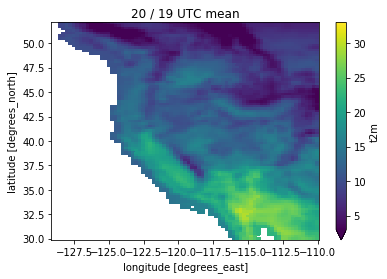

In [17]:
mixed.mean('time').plot(vmin=3,vmax=33)
plt.title('20 / 19 UTC mean')
plt.savefig('/nesi/project/niwa00015/queenle/plots/fire/19_20UTCmean.png')

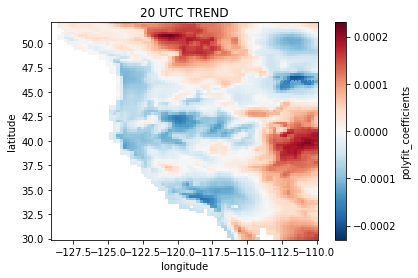

In [53]:
poly_fit = t2m_20.polyfit(dim='time',deg=1,skipna=True)
(poly_fit.polyfit_coefficients.sel(degree=1)* 1e9 * 60 * 60 * 24).plot(vmin=-0.00023,vmax=0.00023,cmap='RdBu_r')
plt.title('20 UTC TREND')
plt.savefig('/nesi/project/niwa00015/queenle/plots/fire/20UTCtrend_1979_2011.png')

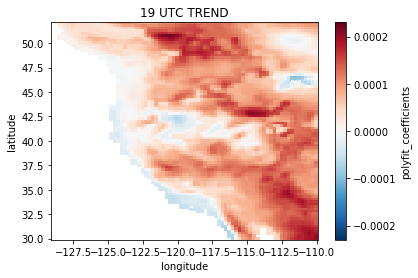

In [54]:
poly_fit = t2m_19.polyfit(dim='time',deg=1,skipna=True)
(poly_fit.polyfit_coefficients.sel(degree=1)* 1e9 * 60 * 60 * 24).plot(vmin=-0.00023,vmax=0.00023,cmap='RdBu_r')
plt.title('19 UTC TREND')
plt.savefig('/nesi/project/niwa00015/queenle/plots/fire/19UTCtrend_1979_2011.png')

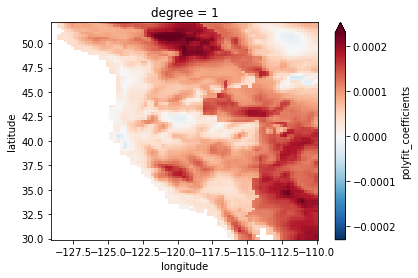

In [33]:
poly_fit = mixed.polyfit(dim='time',deg=1,skipna=True)
(poly_fit.polyfit_coefficients.sel(degree=1)* 1e9 * 60 * 60 * 24).plot(vmin=-0.00023,vmax=0.00023,cmap='RdBu_r')
plt.savefig('/nesi/project/niwa00015/queenle/plots/fire/19_20UTCtrend.png')

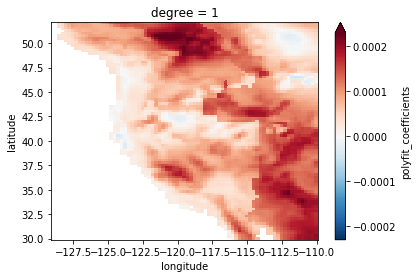

In [8]:
poly_fit = FWI_inputs.t2m.polyfit(dim='time',deg=1,skipna=True)
(poly_fit.polyfit_coefficients.sel(degree=1)* 1e9 * 60 * 60 * 24).plot(vmin=-0.00023,vmax=0.00023,cmap='RdBu_r')


In [39]:
poly_fit.polyfit_coefficients.sel(degree=0).values

array(16.41311521)

0.06406629681469321


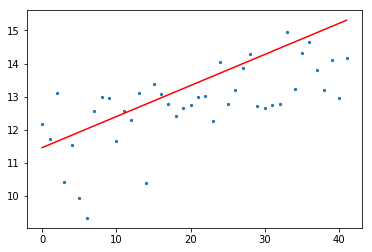

In [60]:
down_cell = both.sel(latitude=43,longitude=-114).resample(time='A').mean().isel(time=slice(0,-1))
plt.scatter([i for i in range(len(down_cell))],down_cell,s=5)

poly_fit = np.polyfit([i for i in range(len(down_cell))],down_cell,deg=1)

intercept = poly_fit[1]#* 1e9 * 60 * 60 * 24
slope = poly_fit[0]# * 1e9 * 60 * 60 * 24

reg = [slope*i + intercept for i in np.linspace(0,60,num=len(down_cell))]
plt.plot(reg,color='red')

print(slope)

0.0737462728747521


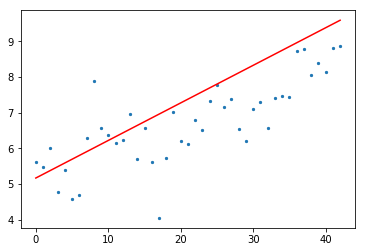

In [51]:
down_cell = both.sel(latitude=50,longitude=-120).resample(time='A').mean().isel(time=slice(0,-1))
plt.scatter([i for i in range(len(down_cell))],down_cell,s=5)

poly_fit = np.polyfit([i for i in range(len(down_cell))],down_cell,deg=1)

intercept = poly_fit[1]#* 1e9 * 60 * 60 * 24
slope = poly_fit[0]# * 1e9 * 60 * 60 * 24

reg = [slope*i + intercept for i in np.linspace(0,60,num=len(down_cell))]
plt.plot(reg,color='red')

print(slope)

In [50]:
both.sel(latitude=50,longitude=-120)

<xarray.DataArray 't2m' (time: 15707)>
array([-24.10498602, -15.79202976, -16.58981438, ..., -15.1155818 ,
       -18.34813639, -19.90742068])
Coordinates:
  * time         (time) datetime64[ns] 1979-01-01 1979-01-02 ... 2022-01-01
    longitude    float32 -120.0
    latitude     float32 50.0
    spatial_ref  int64 0

-4.755279354366202e-06


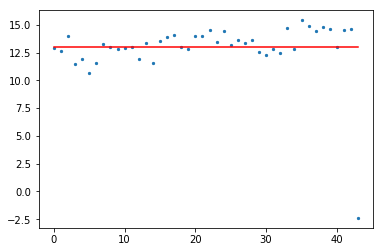

In [45]:
up_cell = both.sel(latitude=40,longitude=-112).resample(time='A').mean()
plt.scatter([i for i in range(len(up_cell))],up_cell,s=5)

poly_fit = up_cell.polyfit(dim='time',deg=1,skipna=True)

intercept = poly_fit.polyfit_coefficients.sel(degree=0).values#* 1e9 * 60 * 60 * 24
slope = (poly_fit.polyfit_coefficients.sel(degree=1).values) * 1e9 * 60 * 60 * 24

reg = [slope*i + intercept for i in np.linspace(0,60,num=len(up_cell))]
plt.plot(reg,color='red')

print(slope)

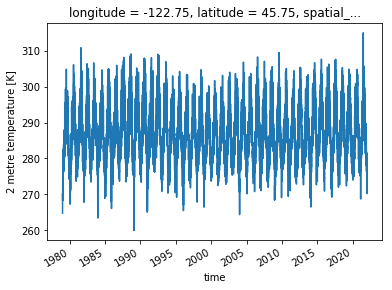

In [17]:
t2m_ln_tz1.isel(latitude=25,longitude=25).plot()

In [4]:
'''
For each time zone: select or sum over (tp) 24h intervals from local noon, find daily temperature max
'''

'''
Time zone 1: PST
'''
# accumulated hourly total precipitation 24 hours prior to local noon
tz1_tp = ERA5_hourly_ds.tp.resample(time="24H", base = tz1_noon_utc, closed="right",label="right").sum().where(tz1_mask.lsm>0, other=0)
tz1_tp['time'] = tz1_tp.indexes['time'].normalize()

# select local noon for non precipitation values
tz1_non_tp_vars = ERA5_hourly_ds.drop('tp')
tz1_non_tp_noon = tz1_non_tp_vars.resample(time="24H", base = tz1_noon_utc, closed="right",label="right").last().where(tz1_mask.lsm>0, other=0)
tz1_non_tp_noon['time'] = tz1_non_tp_noon.indexes['time'].normalize()

tz1_FWI_inputs = xr.merge([tz1_non_tp_noon,tz1_tp])

'''
Time zone 2: MST
'''
# accumulated hourly total precipitation 24 hours prior to local noon
tz2_tp = ERA5_hourly_ds.tp.resample(time="24H", base = tz2_noon_utc, closed="right",label="right").sum().where(tz2_mask.lsm>0,other=0)
tz2_tp['time'] = tz2_tp.indexes['time'].normalize()

# select local noon for non precipitation values
tz2_non_tp_vars = ERA5_hourly_ds.drop('tp')
tz2_non_tp_noon = tz2_non_tp_vars.resample(time="24H", base = tz2_noon_utc, closed="right",label="right").last().where(tz2_mask.lsm>0, other=0)
tz2_non_tp_noon['time'] = tz2_non_tp_noon.indexes['time'].normalize()

tz2_FWI_inputs = xr.merge([tz2_non_tp_noon,tz2_tp])

'''
Combine two local-noon datasets together to single dataset
'''

FWI_inputs = tz1_FWI_inputs + tz2_FWI_inputs
FWI_inputs = FWI_inputs.where((tz1_mask + tz2_mask).lsm > 0)


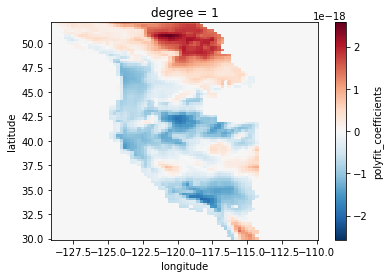

In [19]:
tz1_ERA5 = tz1_FWI_inputs.t2m.sel(time=slice('1979','2011'))

ERA5_poly_fit = tz1_ERA5.polyfit(dim='time',deg=1,skipna=True)
ERA5_poly_fit.sel(degree=1).polyfit_coefficients.plot()#,vmin=-1.5e-17,vmax=1.5e-17,cmap='RdBu_r')


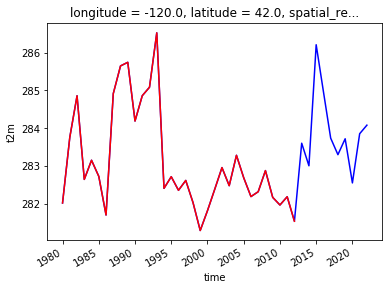

In [31]:
tz1_FWI_inputs.t2m.sel(latitude=42,longitude=-120).resample(time='A').mean().sel(time=slice('1979','2021')).plot(c='blue')
tz1_ERA5.sel(latitude=42,longitude=-120).resample(time='A').mean().sel(time=slice('1979','2021')).plot(c='red')

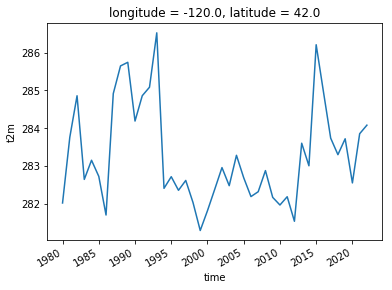

In [43]:
cell = ERA5_hourly_ds.t2m.sel(latitude=42,longitude=-120)

cell_20 = cell.sel(time=cell.time.dt.hour == 20)
cell_20.resample(time='A').mean().plot()

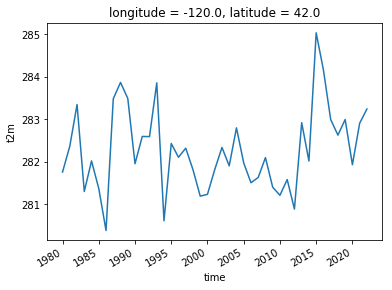

In [44]:
cell_19 = cell.sel(time=cell.time.dt.hour == 19)
cell_19.resample(time='A').mean().plot()

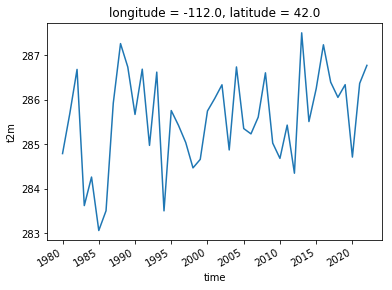

In [48]:
cell = ERA5_hourly_ds.t2m.sel(latitude=42,longitude=-112)

cell_20 = cell.sel(time=cell.time.dt.hour == 20)
cell_20.resample(time='A').mean().plot()

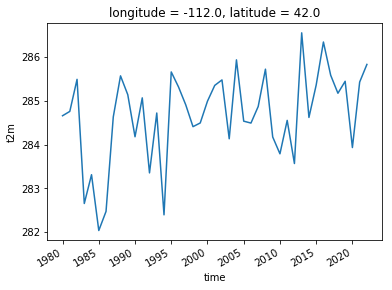

In [49]:
cell_19 = cell.sel(time=cell.time.dt.hour == 19)
cell_19.resample(time='A').mean().plot()

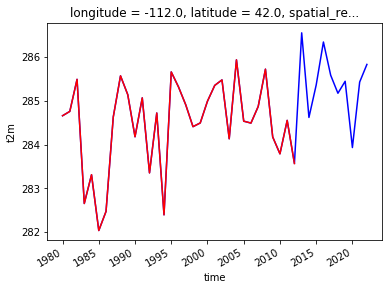

In [30]:
tz2_FWI_inputs.t2m.sel(latitude=42,longitude=-112).resample(time='A').mean().sel(time=slice('1979','2021')).plot(c='blue')
tz2_ERA5.sel(latitude=42,longitude=-112).resample(time='A').mean().sel(time=slice('1979','2021')).plot(c='red')

In [28]:
tz2_ERA5.time

<xarray.DataArray 'time' (time: 12053)>
array(['1979-01-01T00:00:00.000000000', '1979-01-02T00:00:00.000000000',
       '1979-01-03T00:00:00.000000000', ..., '2011-12-29T00:00:00.000000000',
       '2011-12-30T00:00:00.000000000', '2011-12-31T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time         (time) datetime64[ns] 1979-01-01 1979-01-02 ... 2011-12-31
    spatial_ref  int64 0

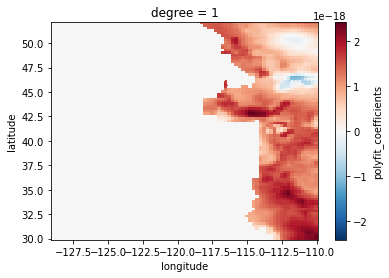

In [20]:
tz2_ERA5 = tz2_FWI_inputs.t2m.sel(time=slice('1979','2011'))

ERA5_poly_fit = tz2_ERA5.polyfit(dim='time',deg=1,skipna=True)
ERA5_poly_fit.sel(degree=1).polyfit_coefficients.plot()#,vmin=-1.5e-17,vmax=1.5e-17,cmap='RdBu_r')


In [47]:
ERA5_poly_fit.isel(latitude=25,longitude=15)

<xarray.Dataset>
Dimensions:               (degree: 2)
Coordinates:
  * degree                (degree) int64 1 0
    latitude              float64 45.75
    longitude             float64 -125.2
Data variables:
    polyfit_coefficients  (degree) float64 0.0 0.0

In [10]:
'''
CONVERT UNITS
'''

#FWI_inputs["t2m"] = FWI_inputs["t2m"] - 273.15 # convert temp K to C
#FWI_inputs["d2m"] = FWI_inputs["d2m"] - 273.15 # convert dew point temp K to C
FWI_inputs["tp"] = FWI_inputs["tp"] * 1000 # convert accumulated precip m to mm

FWI_inputs = FWI_inputs.assign(rh = 100*np.exp((243.04*17.625*(FWI_inputs["d2m"]-FWI_inputs["t2m"]))/((243.04+FWI_inputs["t2m"])*(243.04+FWI_inputs["d2m"]))))
FWI_inputs = FWI_inputs.assign(wind = 3.6 * np.sqrt(FWI_inputs["u10"]**2 + FWI_inputs["v10"]**2))


In [11]:
'''
Remove variables not relevant for FWI calculation
'''

FWI_inputs = FWI_inputs.drop(['u10','v10','d2m'])

In [12]:
'''
Write new netcdf file with FWI input variables to be used by calc_FWI program
'''

FWI_inputs.to_netcdf("/nesi/project/niwa00015/queenle/data/fire/ERA5_FWI_inputs.nc")

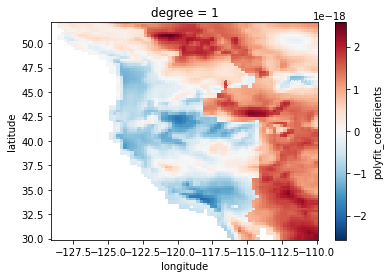

In [17]:
shared_ERA5 = FWI_inputs.t2m.sel(time=slice('1979','2011'))

ERA5_poly_fit = shared_ERA5.polyfit(dim='time',deg=1,skipna=True)
ERA5_poly_fit.sel(degree=1).polyfit_coefficients.plot()#,vmin=-1.5e-17,vmax=1.5e-17,cmap='RdBu_r')


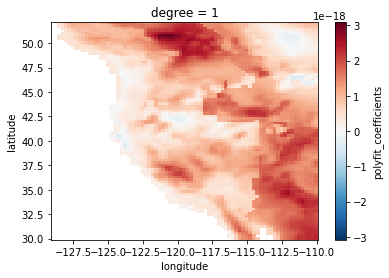

In [18]:
full_ERA5 = FWI_inputs.t2m

ERA5_poly_fit = full_ERA5.polyfit(dim='time',deg=1,skipna=True)
ERA5_poly_fit.sel(degree=1).polyfit_coefficients.plot()#,vmin=-1.5e-17,vmax=1.5e-17,cmap='RdBu_r')


In [30]:
'''
test that resampling is doing what I expect it to do
'''
print('TP')
print('resampled TP (41,-124) at ')
print(tz1_tp.sel(latitude=41,longitude=-124).isel(time=72).time.values)
print(tz1_tp.sel(latitude=41,longitude=-124).isel(time=72).values.tolist())
print()
print('manual selection and sum of (41,-124) 1979-03-13T21:00:00 to 1979-03-14T20:00:00')
print(ERA5_hourly_ds.tp.sel(latitude=41,longitude=-124,time=slice('1979-03-13T21:00:00','1979-03-14T20:00:00')).sum().values.tolist())
print('\n\n')

print('T2M')
print('resampled T2M (41,-124) at')
print(tz1_non_tp_noon.sel(latitude=41,longitude=-124).isel(time=1).time.values)
print(tz1_non_tp_noon.t2m.sel(latitude=41,longitude=-124).isel(time=1).values.tolist())
print()
print('manual selection of (41,-124) at 1979-01-02T20:00:00')
print(ERA5_hourly_ds.t2m.sel(latitude=41,longitude=-124,time='1979-01-02T20:00:00').values.tolist())
print('\n\n')

print('TMAX')
print('resampled TMAX (41,-124) at')
print(tz1_t2m_max.sel(latitude=41,longitude=-124).isel(time=1).time.values)
print(tz1_t2m_max.sel(latitude=41,longitude=-124).isel(time=1).values.tolist())
print()
print('manual selection of (41,-124) at 1979-01-01T21:00:00 to 1979-01-02T20:00:00')
print(ERA5_hourly_ds.t2m.sel(latitude=41,longitude=-124,time=slice('1979-01-01T21:00:00','1979-01-02T20:00:00')).max().values.tolist())

TP
resampled TP (41,-124) at 
1979-03-14T00:00:00.000000000
0.00026335348140013316

manual selection and sum of (41,-124) 1979-03-13T21:00:00 to 1979-03-14T20:00:00
0.0002633534814001331



T2M
resampled T2M (41,-124) at
1979-01-02T00:00:00.000000000
279.99257786449715

manual selection of (41,-124) at 1979-01-02T20:00:00
279.99257786449715



TMAX
resampled TMAX (41,-124) at
1979-01-02T00:00:00.000000000
283.4682055408962

manual selection of (41,-124) at 1979-01-01T21:00:00 to 1979-01-02T20:00:00
283.4682055408962
